# 01 – Generate initial data

This notebook sources the script `01_generate_initial_data.jl`.
Open that script to choose a 2D or 1D configuration.

In [2]:
#include("01_generate_initial_data.jl")

In [1]:
# 01 – Generate initial data
# This script generates particle initial conditions for the refactored PIC code.
# It supports all 2D configurations used in run_2D_clean.ipynb plus the 1D
# Landau-damping family from ini_dat_v2.ipynb.
#
# Pick one configuration in the section you want (2D or 1D) and run the script.

using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

cd(@__DIR__)
include(joinpath("..", "src", "PIC.jl"))
using .PIC
#ENV["GKSwstype"] = "nul"   # headless GR backend for terminal use
using Plots
using Statistics
using FFTW
using LinearAlgebra

  Activating project at `~/Julia/PIC/PIC_refactor`
Precompiling packages...
   4518.6 ms  ✓ StaticArrays
   1362.7 ms  ✓ Adapt → AdaptStaticArraysExt
   1370.1 ms  ✓ ConstructionBase → ConstructionBaseStaticArraysExt
   1377.8 ms  ✓ StaticArrays → StaticArraysStatisticsExt
   1424.0 ms  ✓ Accessors → StaticArraysExt
    532.4 ms  ✓ StaticArrayInterface → StaticArrayInterfaceStaticArraysExt
    845.1 ms  ✓ SciMLBase → SciMLBaseStaticArraysExt
    996.8 ms  ✓ FastGaussQuadrature
   1245.7 ms  ✓ PolynomialBases
  15799.7 ms  ✓ JLD2
   8256.7 ms  ✓ SummationByPartsOperators
   1222.2 ms  ✓ JLD2 → UnPackExt
   1105.3 ms  ✓ PIC
  13 dependencies successfully precompiled in 19 seconds. 128 already precompiled.
  27 dependencies precompiled but different versions are currently loaded (ArgTools, Base64, Dates, Downloads, InteractiveUtils, JuliaSyntaxHighlighting, LibCURL, LibCURL_jll, LibGit2, LibGit2_jll, LibSSH2_jll, Logging, Markdown, Mmap, MozillaCACerts_jll, NetworkOptions, OpenSSL_jll, Pk

The shape constants, the order of smoothness and the factor (the dilation of the shape). Factors bigger than one increase the size of the region where the density and current need to be computed, but gives much more smooths Maxwell fields.

In [2]:
const order = 5 #shape smoothness
const factor = 2 # shape dilation

2

In [3]:

# -------------------------------------------------
# 2D configurations (mirroring run_2D_clean.ipynb)
# -------------------------------------------------
# Available options:
#   :thermal      – relativistic thermal with cosine perturbation
#   :weibel_norel – non-relativistic Weibel anisotropic distribution
#   :weibel_rel   – relativistic two-stream Weibel (Morozov–Nielsen)
#
#   (the damped Landau case is 1D – see the 1D block below)
#
config_name = :thermal   # :thermal, :weibel_norel, :weibel_rel

cfg = make_config(config_name)
@show cfg.name
@show cfg.N
@show cfg.J
@show cfg.box
@show cfg.data_name

# Generate and save the 2D particle distribution
data_path = joinpath("..", "Initial_Distributions", cfg.data_name)

par_dis = build_initial_data_D(
    data_path,
    cfg.N,
    cfg.f_x, cfg.f_x_max, cfg.par_f_x, cfg.box,
    cfg.f_p, cfg.f_p_max, cfg.par_f_p, cfg.box_p
)

println("Saved to: Initial_Distributions/$(cfg.data_name).jld2")
println("length(par_dis) = ", length(par_dis))

cfg

cfg.name = :thermal
cfg.N = 100000
cfg.J = (50, 50)
cfg.box = Box{2}([0.0, 0.0], [1.0, 1.0])
cfg.data_name = "par_dis_rel_thermal_nm_[1,1]_alp1_N5_Th3"
Saved to: Initial_Distributions/par_dis_rel_thermal_nm_[1,1]_alp1_N5_Th3.jld2
length(par_dis) = 400000


(name = :thermal, N = 100000, J = (50, 50), box = Box{2}([0.0, 0.0], [1.0, 1.0]), box_bounds = (0.0, 1.0, 0.0, 1.0), nm = [1, 1], alpha_exp = 1, theta_exp = 3, alpha = 0.1, theta = 0.001, f_p = Main.PIC.f_p_thermal, f_p_max = Main.PIC.f_p_thermal_max, par_f_p = (0.001, 2), box_p = Box{2}([-0.14177446878757827, -0.14177446878757827], [0.14177446878757827, 0.14177446878757827]), f_x = Main.PIC.f_x, f_x_max = Main.PIC.f_x_max, par_f_x = (0.1, [1, 1], Box{2}([0.0, 0.0], [1.0, 1.0])), data_name = "par_dis_rel_thermal_nm_[1,1]_alp1_N5_Th3", run_name = "thermal_rel_Box_1.0x1.0_J_50x50_nm_[1,1]_Th3_alp1")

Some diagnostics

In [ ]:



N = cfg.N
r = reshape(par_dis, (4, N))'
x  = r[:, 1]
y  = r[:, 2]
px = r[:, 3]
py = r[:, 4]

# Minimal state for module diagnostics
g_dummy = PICGrid(cfg.box, cfg.J, order)
u_dummy = make_state(g_dummy, N)
u_dummy[1:4N] .= par_dis;



### For the thermal configurations

For other configurations you have to do it. The parameters configurations are in the structure cfg

In [5]:
T_rel   = temperature(u_dummy, g_dummy, N; mode=:rel)
T_norel = temperature(u_dummy, g_dummy, N; mode=:norel)
println("relativistic temperature T = ", T_rel) #, "  (target θ = ", cfg.theta, ")")
println("non-relativistic temperature T = ", T_norel) #, "  (target θ = ", cfg.theta, ")")

P_total = total_momentum(u_dummy, g_dummy, N)
println("total momentum P = ", P_total)
println("|P|/N = ", norm(P_total) / N)

println("x range:  ", extrema(x))
println("y range:  ", extrema(y))
println("<px^2> = ", mean(px.^2), "  (target θ = ", cfg.theta, ")")
println("<py^2> = ", mean(py.^2), "  (target θ = ", cfg.theta, ")")


relativistic temperature T = 0.0010036010382852962
non-relativistic temperature T = 0.001003601038285274
total momentum P = [-1.970645868709653e-15, -2.5146551507759796e-14]
|P|/N = 2.5223649574799416e-19
x range:  (2.9054534033123858e-6, 0.999987178938307)
y range:  (2.2588052334127084e-6, 0.9999983944922409)
<px^2> = 0.0010065472651732078  (target θ = 0.001)
<py^2> = 0.0010006548113973793  (target θ = 0.001)


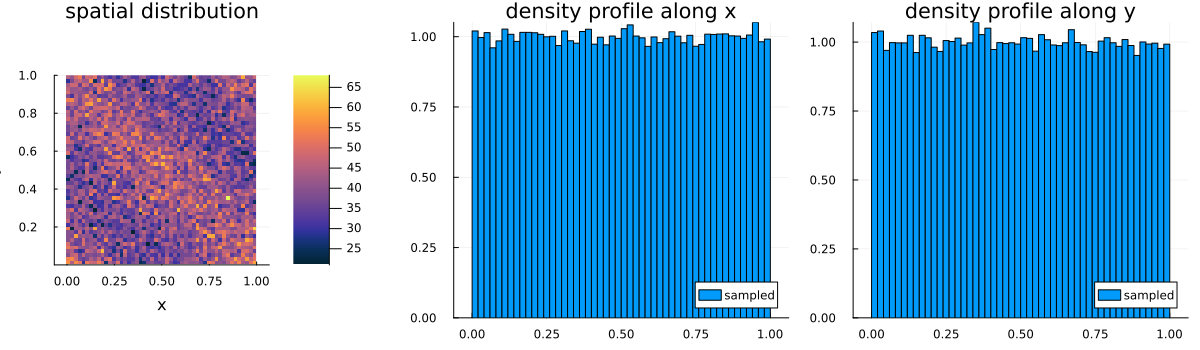

In [6]:


# Spatial plots
h2 = histogram2d(x, y, bins=50,
    title="spatial distribution", c=:thermal, aspectratio=1,
    xlabel="x", ylabel="y")

hx = histogram(x, bins=50, normalize=true, label="sampled", title="density profile along x")
#kx = 2π * cfg.nm[1] / extent(cfg.box, 1)
#analytic_x = xx -> (1 + cfg.alpha * cos(kx * xx)) / extent(cfg.box, 1)
#xx = range(cfg.box.lo[1], cfg.box.hi[1], length=200)
#plot!(hx, xx)#, analytic_x.(xx), lw=2, label="analytic")

hy = histogram(y, bins=50, normalize=true, label="sampled", title="density profile along y")
#ky = 2π * cfg.nm[2] / extent(cfg.box, 2)
#analytic_y = yy -> (1 + cfg.alpha * cos(ky * yy)) / extent(cfg.box, 2)
#yy = range(cfg.box.lo[2], cfg.box.hi[2], length=200)
#plot!(hy, yy), analytic_y.(yy), lw=2, label="analytic")

plot(h2, hx, hy, layout=(1, 3), size=(1200, 350))



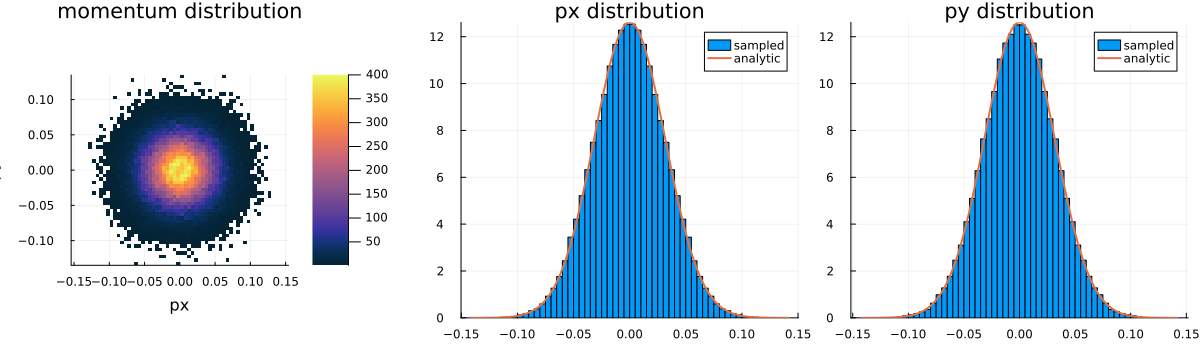

In [7]:


# Momentum plots
mp2 = histogram2d(px, py, bins=50,
    title="momentum distribution", c=:thermal, aspectratio=1,
    xlabel="px", ylabel="py")

θ = cfg.theta #for thermal
#θ = cfg.theta1 #for weibel but does not reflex the correct distribution

p_max = cfg.box_p.hi[1]
analytic_p = pp -> exp(-pp.^2 / θ / 2) / sqrt(θ * π * 2)
pp = range(-p_max, p_max, length=200)

hpx = histogram(px, bins=50, normalize=true, label="sampled", title="px distribution")
plot!(hpx, pp, analytic_p.(pp), lw=2, label="analytic")

hpy = histogram(py, bins=50, normalize=true, label="sampled", title="py distribution")
plot!(hpy, pp, analytic_p.(pp), lw=2, label="analytic")

plot(mp2, hpx, hpy, layout=(1, 3), size=(1200, 350))


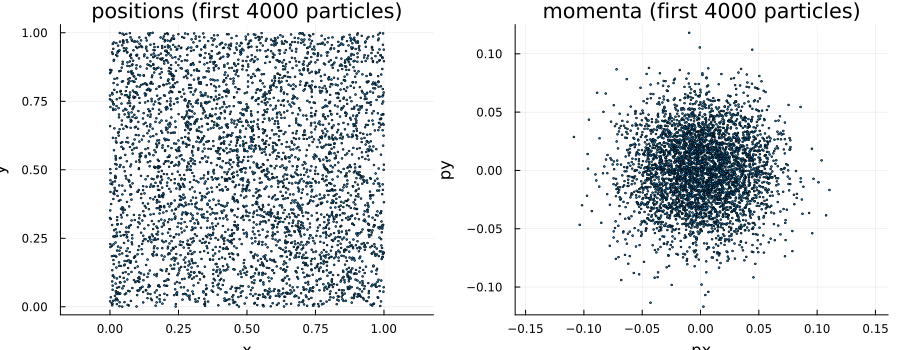

In [8]:

# Scatter plots of the first few thousand particles
nplot = min(N, 4000)
p1 = scatter(x[1:nplot], y[1:nplot],
    title="positions (first $nplot particles)", aspectratio=1,
    xlabel="x", ylabel="y", markersize=1, label=false)
p2 = scatter(px[1:nplot], py[1:nplot],
    title="momenta (first $nplot particles)", aspectratio=1,
    xlabel="px", ylabel="py", markersize=1, label=false)
plot(p1, p2, layout=(1, 2), size=(900, 350))


## 1D configurations

In [9]:
# -------------------------------------------------
# 1D Landau-damping configurations
# -------------------------------------------------
# Available options (from ini_dat_v2.ipynb):
#   :undamped_l     – L = 39.738, m = 2
#   :undamped_s     – L = 4.0,    m = 2
#   :vlasov_exp_200 – L = 200.0,  m = 10
#   :vlasov_exp_40  – L = 40.0,   m = 2
#   :damped         – L = 7.455,  m = 15 (also try m = 12 or 19)
#
# To use this section, comment out the 2D block above and uncomment the
# lines below, then run the script again.

config_name_1d = :damped   # :undamped_l, :undamped_s, :vlasov_exp_200 :vlasov_exp_40, :damped
cfg1 = make_config_1d(config_name_1d)
@show cfg1.name
@show cfg1.N
@show cfg1.L
@show cfg1.m
@show cfg1.data_name



cfg1.name = :landau_1d_damped
cfg1.N = 8000000
cfg1.L = 7.455
cfg1.m = 15
cfg1.data_name = "par_dis_landau_norm_norel_damped_15_alp2_86_Th3"


"par_dis_landau_norm_norel_damped_15_alp2_86_Th3"

In [10]:
data_path_1d = joinpath("..", "Initial_Distributions", cfg1.data_name)
par_dis_1d = build_initial_data_D(
    data_path_1d,
    cfg1.N,
    cfg1.f_x, cfg1.f_x_max, cfg1.par_f_x, cfg1.box,
    cfg1.f_p, cfg1.f_p_max, cfg1.par_f_p, cfg1.box_p
)
println("Saved to: Initial_Distributions/$(cfg1.data_name).jld2")
println("length(par_dis_1d) = ", length(par_dis_1d))


Saved to: Initial_Distributions/par_dis_landau_norm_norel_damped_15_alp2_86_Th3.jld2
length(par_dis_1d) = 16000000


### Diagnosis

In [11]:
# Minimal configuration to run diagnosis
# Interleaved layout [x1, p1, x2, p2, ...] (one block per particle), as in the
# D-generic builder and make_state: positions at odd slots, momenta at even ones.
N1 = cfg1.N
x1 = par_dis_1d[1:2:end]
p1 = par_dis_1d[2:2:end]

g1_dummy = PICGrid(cfg1.box_x, cfg1.J, order)
u1_dummy = make_state(g1_dummy, N1)
u1_dummy[1:2N1] .= par_dis_1d;


In [29]:
#x1[1:4000]
#p1[1:4000]

In [12]:


T1_rel = temperature(u1_dummy, g1_dummy, N1; mode=:rel)
println("1D relativistic temperature T = ", T1_rel, "  (target θ = ", cfg1.theta, ")")
P1_total = total_momentum(u1_dummy, g1_dummy, N1)


1D relativistic temperature T = 0.0010013745515058613  (target θ = 0.001)


1-element StaticArraysCore.SVector{1, Float64} with indices SOneTo(1):
 -3.0890012769901887e-12

1D total momentum P = [-3.0890012769901887e-12]
|P|/N = [-3.861251596237736e-19]
x range: (5.555392275485849e-7, 7.4549991303730065)
p range: (-0.14171982677745298, 0.14171982677745298)


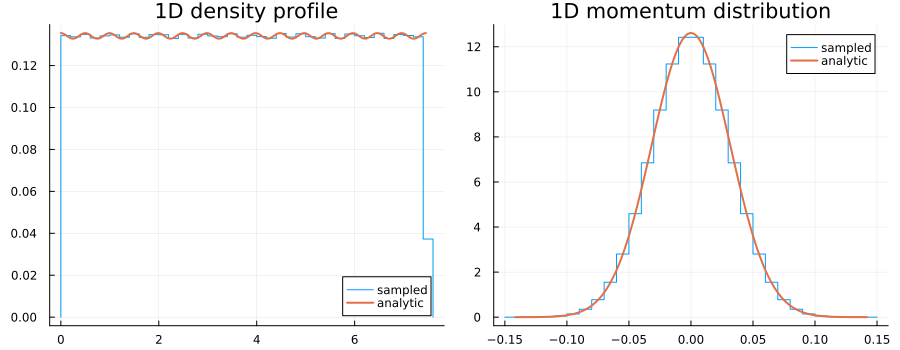

In [13]:

println("1D total momentum P = ", P1_total)
println("|P|/N = ", P1_total ./ N1)
println("x range: ", extrema(x1))
println("p range: ", extrema(p1))

h_x1 = histogram(x1, bins=50, normalize=true, label="sampled", title="1D density profile")
k1 = 2π * cfg1.m / cfg1.L
analytic_x1 = xx -> (1 + cfg1.alpha * cos(k1 * xx)) / cfg1.L
xx1 = range(cfg1.box_x.lo[1], cfg1.box_x.hi[1], length=200)
plot!(h_x1, xx1, analytic_x1.(xx1), lw=2, label="analytic")

θ1 = cfg1.theta
norm1 = cfg1.par_f_p[2]
analytic_p1 = pp -> exp((1 - sqrt(1 + pp^2)) / θ1) / sqrt(θ1 * π * 2) / norm1
p_max1 = cfg1.box_p.hi[1]
pp1 = range(-p_max1, p_max1, length=200)
h_p1 = histogram(p1, bins=50, normalize=true, label="sampled", title="1D momentum distribution")
plot!(h_p1, pp1, analytic_p1.(pp1), lw=2, label="analytic")

plot(h_x1, h_p1, layout=(1, 2), size=(900, 350))


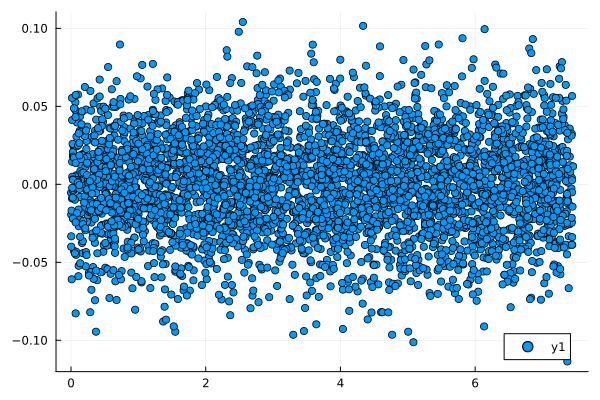

In [14]:
scatter(x1[1:4000],p1[1:4000])